## Data Exploration & Cleaning

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/stzh.zwn_meldungen_p.csv") #importing the dataset and calling it "df"
df.head()


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14T15:16:15,2013-04-04T07:25:05,2013-04-12T07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14T15:17:57,2013-03-26T14:05:05,2013-04-12T08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15T09:14:16,2013-03-15T09:55:05,2013-04-12T08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15T09:17:15,2013-03-20T10:05:05,2013-04-12T08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15T10:36:53,2013-04-22T18:25:05,2013-04-23T13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


Now I have the data, I want to check to find where the types of incidents are listed(graffiti, vandalism, etc.), so:

In [2]:
df["service_name"].unique() #unique values in service_name

<ArrowStringArray>
[   'Strasse/Trottoir/Platz',       'Abfall/Sammelstelle',
   'Grünflächen/Spielplätze',         'Beleuchtung/Uhren',
                  'Graffiti', 'Signalisation/Lichtsignal',
         'Brunnen/Hydranten',                    'VBZ/ÖV',
                 'Allgemein',                'Schädlinge']
Length: 10, dtype: str

In [3]:
df["geometry"].head() #spatial geometry of point of each incident


0    POINT (2678968 1247548)
1    POINT (2680746 1249916)
2    POINT (2684605 1251431)
3    POINT (2681754 1250376)
4    POINT (2683094 1247762)
Name: geometry, dtype: str

Each incident has a geographical point location, likely using Swiss projection coordinates(e.g. Swiss CRS EPSG: 2056 projection). Also "dtype:str" signals that the data is stored in the form of text strings, thus will need to be transformed into spatial objects. This means transforming the dataframe into a GeoDataFrame, so that these text strings can be converted to real geographical locations and can be mapped or spatially joined.

In [4]:
df["service_name"].value_counts() #number of incidents for each event

service_name
Abfall/Sammelstelle          27445
Signalisation/Lichtsignal    10984
Strasse/Trottoir/Platz        9874
Grünflächen/Spielplätze       7254
Beleuchtung/Uhren             5414
Allgemein                     3977
Graffiti                      3780
VBZ/ÖV                        1886
Brunnen/Hydranten             1295
Schädlinge                     895
Name: count, dtype: int64

For this analysis, relevant columns are "requested_datetime", "service_name","geometry", and perhaps "title" and "status"

In [5]:
cleaned_df = df[["requested_datetime", "service_name","status","title","geometry"]] #creating the new dataset with
#relevant columns
cleaned_df.head()

,requested_datetime,service_name,status,title,geometry
0,2013-03-14T15:16:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,POINT (2678968 1247548)
1,2013-03-14T15:17:57,Strasse/Trottoir/Platz,fixed - council,Vermessungs,POINT (2680746 1249916)
2,2013-03-15T09:14:16,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,POINT (2684605 1251431)
3,2013-03-15T09:17:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,POINT (2681754 1250376)
4,2013-03-15T10:36:53,Abfall/Sammelstelle,fixed - council,Arbeitskist,POINT (2683094 1247762)


Now we have the dataframe with the relevant columns, we can convert the text strings into geometry objects using GeoPandas and Well-Known Text from Shapely, so:

In [6]:
import geopandas as gpd #for working with spatial data
from shapely import wkt #for converting text strings into spatial objects

Now we convert the geometry column values into spatial data, so:

In [7]:
cleaned_df["geometry"] = cleaned_df["geometry"].apply(wkt.loads) #this converts text strings into Shapely Points

The error shows how it was expected to be working with bytes or strings but it actually was Point data in the geometry column, signalling that the dataset is already close to a GeoDataFrame. Now we can create the GeoDataFrame, so:

In [8]:
zurich_gdf = gpd.GeoDataFrame(cleaned_df, geometry="geometry", crs="EPSG:2056") # added CRS so it is usable in other systems(according to error)

type(zurich_gdf)#verify that the type of the dataset is a GeoDataFrame

geopandas.geodataframe.GeoDataFrame

<Axes: >

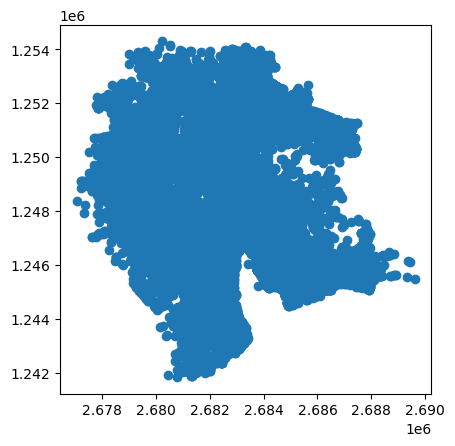

In [9]:
zurich_gdf.plot()#the data is working when we map it too

In [10]:
zurich_gdf.to_file("../data/processed/zurich_gdf.gpkg") #save the data to the folder to work with later

## Importing Zurich district polygons for spatial joining

Now that the GeoDataFrame of point data per incident has been created, it can be spatially joined to begin analyzing incidents across different areas of Zurich. Thus, we will therefor need polygon data of areas in Zurich for analysis. To do this, the "Statistische Quartier" geopackage was chosen which includes polygons of each quartier of Zurich. This will allow us to sort the incidents into their respective quartier. 

In [32]:
import geopandas as gpd

zurich_quartier_polygons = gpd.read_file("../data/raw/data.gpkg")

C:\Users\Emily Rose\miniconda3\envs\sds-env\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'data.gpkg': 'stzh.adm_statistische_quartiere_b_p' (default), 'stzh.adm_statistische_quartiere_v', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


Now lets inspect the dataset

In [33]:
zurich_quartier_polygons.head()

,objid,objectid,ori,hali,vali,name,kuerzel,geometry
0,1,1,0.0,1.0,2.0,Affoltern,111,POINT (2680575.711 1253034.933)
1,2,2,0.0,1.0,2.0,Seebach,119,POINT (2683071.957 1253148.375)
2,3,3,0.0,1.0,2.0,Saatlen,121,POINT (2684968.446 1251835.404)
3,4,4,0.0,1.0,2.0,Höngg,101,POINT (2679781.451 1251349.147)
4,5,5,0.0,1.0,2.0,Wipkingen,102,POINT (2681888.652 1250165.853)


In [34]:
zurich_quartier_polygons.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [35]:
zurich_quartier_polygons.geom_type.unique()

<ArrowStringArray>
['Point']
Length: 1, dtype: str

The CRS is indeed correct, as was listed on the dataset website. However, the dataset is listed as point data. The user warning after creating the zurich_quartier_polygons object indicates that there is more than one layer in the dataset, and this point layer is likely denoting the centroid of each quartier. Therefore, we must select the correct layer associated with the quartier polygons themselves. The likely layer is "stzh.adm_statistische_quartiere_map", so we select it when defining the object.

In [36]:
zurich_quartier_polygons = gpd.read_file("../data/raw/data.gpkg", layer="stzh.adm_statistische_quartiere_map")

Now we check the geometry type to see if its polygon data.

In [37]:
zurich_quartier_polygons.geom_type.unique()

<ArrowStringArray>
['Polygon']
Length: 1, dtype: str

Now we see it is the polygon layer, and we can plot it to see if it actually is the quartier polygons.

<Axes: >

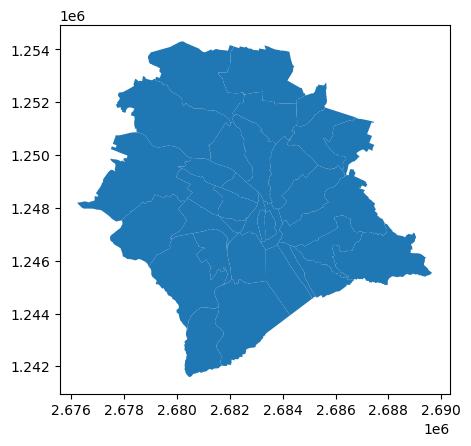

In [38]:
zurich_quartier_polygons.plot()

It is the correct layer, now we just double-check that both the incident point data and the polygon data are in the same CRS before spatially joining them.

In [39]:
zurich_gdf.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [40]:
zurich_quartier_polygons.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

They are both in the same CRS(EPSG: 2056) and are ready for spatial joining. This joint dataset will be the main foundational dataset for this analysis, so we must assure quality and give it a representative name. 

In [43]:
zurich_qi = gpd.sjoin( #spatially join the two datasets, "qi" is quartier incidents
    zurich_gdf, zurich_quartier_polygons,
    how = "left", #keep all the incident data points, even if some dont fall in a polygon
    predicate = "within" #describes to find which polygon each point falls within
) 

Now we check the joined dataframe to see if we have each incident(service_name) with an associated neighbourhood(qname).

In [44]:
zurich_qi.head()

,requested_datetime,service_name,status,title,geometry,index_right,objectid,qnr,qname,knr,kname
0,2013-03-14T15:16:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,POINT (2678968 1247548),6.0,9.0,91.0,Albisrieden,9.0,Kreis 9
1,2013-03-14T15:17:57,Strasse/Trottoir/Platz,fixed - council,Vermessungs,POINT (2680746 1249916),10.0,19.0,101.0,Höngg,10.0,Kreis 10
2,2013-03-15T09:14:16,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,POINT (2684605 1251431),26.0,26.0,121.0,Saatlen,12.0,Kreis 12
3,2013-03-15T09:17:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,POINT (2681754 1250376),21.0,17.0,102.0,Wipkingen,10.0,Kreis 10
4,2013-03-15T10:36:53,Abfall/Sammelstelle,fixed - council,Arbeitskist,POINT (2683094 1247762),22.0,22.0,14.0,City,1.0,Kreis 1


We must also save this new joined dataset too.

In [45]:
zurich_qi.to_file("../data/processed/incidents_joined_quartiers.gpkg", driver = "GPKG"